# Backtesting

Imports

In [43]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
from dotenv import load_dotenv
from fredapi import Fred
import numpy as np

### Step 1: Load cointegration and price data

In [44]:
data_folder_path = Path("data")
print(data_folder_path.exists())

True


In [45]:
bh_corrected_df = pd.read_parquet(data_folder_path / "bh_corrected_results.parquet")
bh_sig_results_df = bh_corrected_df[bh_corrected_df["bh_reject"]]
sig_results_df = pd.read_parquet(data_folder_path / "sig_results.parquet")

In [46]:
print(sig_results_df.head())

                                 correlation   coint_t   p_value  \
formation_end ticker_0 ticker_1                                    
2016-01-01    STT      GS           0.753596 -3.362022  0.046747   
                       MS           0.739525 -4.778833  0.000411   
                       LNC          0.776851 -3.481309  0.034089   
              COP      EOG          0.781141 -3.454777  0.036620   
              KIM      O            0.762781 -4.339056  0.002224   

                                 critical_1pct  critical_5pct  critical_10pct  \
formation_end ticker_0 ticker_1                                                 
2016-01-01    STT      GS            -3.918346      -3.348304       -3.052893   
                       MS            -3.918346      -3.348304       -3.052893   
                       LNC           -3.918346      -3.348304       -3.052893   
              COP      EOG           -3.918346      -3.348304       -3.052893   
              KIM      O             

In [47]:
print(bh_corrected_df.head())

                                 correlation   coint_t   p_value  \
formation_end ticker_0 ticker_1                                    
2016-01-01    SWKS     AVGO         0.705393 -0.019827  0.985429   
              BAC      STT          0.730833 -2.431513  0.310079   
                       HBAN         0.767496 -2.654967  0.216192   
                       PFG          0.710855 -2.270825  0.388197   
                       TFC          0.756456 -2.563165  0.251944   

                                 critical_1pct  critical_5pct  critical_10pct  \
formation_end ticker_0 ticker_1                                                 
2016-01-01    SWKS     AVGO          -3.918346      -3.348304       -3.052893   
              BAC      STT           -3.918346      -3.348304       -3.052893   
                       HBAN          -3.918346      -3.348304       -3.052893   
                       PFG           -3.918346      -3.348304       -3.052893   
                       TFC           

In [48]:
historical_ohlcv_df = pd.read_parquet(data_folder_path / "historical_ohlcv_df.parquet")

In [49]:
print(historical_ohlcv_df.head())

Ticker      PCL                        LLL                           ...  \
Price      Open High Low Close Volume Open High Low Close Adj Close  ...   
Date                                                                 ...   
2014-01-02  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN       NaN  ...   
2014-01-03  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN       NaN  ...   
2014-01-06  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN       NaN  ...   
2014-01-07  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN       NaN  ...   
2014-01-08  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN       NaN  ...   

Ticker           ACGL                                                 ROST  \
Price            Open       High        Low      Close   Volume       Open   
Date                                                                         
2014-01-02  18.783414  18.875336  18.162162  18.184349  2592900  32.832875   
2014-01-03  18.152653  18.219215  17.753275  17.835686  3620400  32.819630   
2

### Step 2: Estimate relationship parameters for all pairs

In [50]:
close_prices = historical_ohlcv_df.xs("Close", level="Price", axis=1)
print(close_prices.head())

Ticker      PCL  LLL  GMCR  MRO  ETFC  DO  RTN  GGP  NFX  LEG  ...        XEL  \
Date                                                           ...              
2014-01-02  NaN  NaN   NaN  NaN   NaN NaN  NaN  NaN  NaN  NaN  ...  18.308685   
2014-01-03  NaN  NaN   NaN  NaN   NaN NaN  NaN  NaN  NaN  NaN  ...  18.302029   
2014-01-06  NaN  NaN   NaN  NaN   NaN NaN  NaN  NaN  NaN  NaN  ...  18.202192   
2014-01-07  NaN  NaN   NaN  NaN   NaN NaN  NaN  NaN  NaN  NaN  ...  18.514999   
2014-01-08  NaN  NaN   NaN  NaN   NaN NaN  NaN  NaN  NaN  NaN  ...  18.441788   

Ticker            APA         CMI        AWK          D        WAB       NDAQ  \
Date                                                                            
2014-01-02  63.316505   99.743729  31.939985  37.304127  68.494621  10.673878   
2014-01-03  63.360950  100.175621  31.847795  37.263054  68.934059  10.831811   
2014-01-06  63.931301   99.858910  31.724890  37.268929  68.148705  10.859035   
2014-01-07  65.109055  100.

Create a function to estimate params for a pair

In [51]:
def estimate_params(ticker_0, ticker_1, formation_start, formation_end):
    pair_prices = close_prices.loc[
        formation_start:(formation_end - pd.DateOffset(days=1)),
        [ticker_0, ticker_1]
    ].dropna()

    y = pair_prices[ticker_0]
    x = pair_prices[ticker_1]

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    alpha = model.params["const"]
    beta = model.params[ticker_1]

    spread = y - (alpha + beta * x)

    return alpha, beta, spread.mean(), spread.std()

In [52]:
print(estimate_params("AAPL", "MSFT", pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31")))

(np.float64(-70.92462209671135), np.float64(0.8908157356582398), np.float64(3.620384415539558e-14), np.float64(7.600240592432756))


Create a function to estimate params for all pairs in a window and store in a dataframe

In [53]:
def estimate_params_for_window(pairs, formation_start, formation_end):
    results = []

    for ticker_0, ticker_1 in pairs:
        alpha, beta, spread_mean, spread_std = estimate_params(ticker_0, ticker_1, formation_start, formation_end)
        results.append({
            "formation_end": formation_end,
            "ticker_0": ticker_0,
            "ticker_1": ticker_1,
            "alpha": alpha,
            "beta": beta,
            "spread_mean": spread_mean,
            "spread_std": spread_std
        })
    return pd.DataFrame(results).set_index(["formation_end", "ticker_0", "ticker_1"])

Create a function to estimate params for all windows in a dataframe of cointegration data. We will call this function twice: once on the raw p-value threshold data and once on the BH-corrected data.

In [54]:
def estimate_params_for_all_windows(coint_df, window_size=504):
    results = []

    formation_ends = coint_df.index.get_level_values("formation_end").unique()

    for formation_end in formation_ends:
        end_idx = close_prices.index.searchsorted(formation_end, side="left") - 1
        formation_start = close_prices.index[end_idx - (window_size - 1)]

        pairs = coint_df.loc[formation_end].index.tolist()

        window_params_df = estimate_params_for_window(
            pairs,
            formation_start,
            formation_end
        )

        results.append(window_params_df)

    return pd.concat(results, ignore_index=False)

Estimate params for both sig_results_df and bh_corrected_df

In [55]:
sig_window_params_df = estimate_params_for_all_windows(sig_results_df)
bh_window_params_df = estimate_params_for_all_windows(bh_sig_results_df)

In [56]:
sig_window_params_df

alpha      beta   spread_mean  spread_std
formation_end ticker_0 ticker_1                                               
2016-01-01    STT      GS        15.529632  0.254871 -2.047040e-13    1.591032
                       MS        15.050681  1.496055  1.467045e-13    1.330992
                       LNC        9.530156  1.223589 -1.684719e-14    1.630143
              COP      EOG       -8.118955  0.813194 -1.037054e-13    2.007876
              KIM      O          0.943564  0.495747 -7.820904e-15    0.274850
...                                    ...       ...           ...         ...
2026-01-01    MET      MTB       36.637323  0.220793  5.936697e-14    2.304742
              CFG      AXP       -0.003349  0.147049  6.132661e-14    2.151317
              AXP      MS        68.444542  1.757341 -4.849736e-15   11.097357
              COF      WFC       -7.395712  2.698647  3.236917e-14    7.228975
              GIS      CAG       14.885463  1.787903 -2.481260e-15    1.451645

[14542 rows x 4 columns]

In [57]:
bh_window_params_df

alpha      beta   spread_mean  spread_std
formation_end ticker_0 ticker_1                                               
2016-01-01    XEL      CMS        3.514137  0.847090 -9.868649e-14    0.228813
2016-02-01    XEL      CMS        3.464457  0.849943  8.074670e-14    0.236661
2016-03-01    STT      MS        10.544865  1.664574  3.214360e-14    1.125561
              XEL      CMS        3.481570  0.849850  2.403721e-15    0.234388
2016-04-01    STT      MS        11.365381  1.633517 -4.821540e-15    1.122996
...                                    ...       ...           ...         ...
2025-11-01    PPL      NI         8.675948  0.647139  1.603655e-14    0.611208
              CPT      ESS        3.367895  0.392093  1.248243e-13    2.017917
              RF       KEY       -1.634339  1.484203  3.118493e-14    0.445216
2025-12-01    CPT      ESS        2.656223  0.394576 -1.001527e-13    2.043802
              RF       KEY       -2.206337  1.521070  1.239220e-14    0.419373

[406 rows x 4 columns]

### Step 3: Simulate trading using formation window data

Since we will want Sharpe ratios, we will first obtain 3-month T-bill rates over the 10-year period to use as an approximation for the risk-free rate. We will obtain these rates from the FRED API.

In [71]:
load_dotenv()

fred_api_key = os.getenv("FRED_API_KEY")

if not fred_api_key:
    raise ValueError("FRED_API_KEY environment variable not set.")

fred = Fred(api_key=fred_api_key)
t_bill_data = fred.get_series("DGS3MO", "2015-12-01", "2026-01-02") # fetch extra data for backfilling later

print(t_bill_data)

2015-12-01    0.21
2015-12-02    0.21
2015-12-03    0.21
2015-12-04    0.23
2015-12-07    0.29
              ... 
2025-12-29    3.68
2025-12-30    3.65
2025-12-31    3.67
2026-01-01     NaN
2026-01-02    3.65
Length: 2634, dtype: float64


Calculate z-score from 2 prices

In [72]:
def calculate_z_score(price_0, price_1, alpha, beta, spread_mean, spread_std):
    spread = price_0 - (alpha + beta * price_1) # y is ticker_0, x is ticker_1 according to our earlier code
    return (spread - spread_mean) / spread_std

In [73]:
TRADE_THRESH = 2 # only trade if absolute value of z-score is > 2
SELL_THRESH = 0.5 # we will sell our current portfolio if absolute value of z score < 0.5
TRADE_NOMINAL = 10_000 # spend $10k per trade
TRANSACTION_COST_RATE = 0.0005 # 5 bps per trade
MAX_HOLDING_DAYS = 365
INITIAL_CAPITAL = 1_000_000.0

Function to open a position

In [74]:
def open_position(gross_cash_deployed, open_positions, ticker_0, ticker_1, formation_end, direction, signal_date, entry_date, entry_z, alpha, beta, q0, q1, entry_price_0, entry_price_1):
    pair = (ticker_0, ticker_1)

    if pair in open_positions:
        raise ValueError(f"Position for pair {pair} is already open.")

    entry_gross_exposure = abs(q0 * entry_price_0) + abs(q1 * entry_price_1)
    entry_cost = TRANSACTION_COST_RATE * entry_gross_exposure
    gross_cash_deployed += entry_gross_exposure

    open_positions[pair] = {
        "formation_end": formation_end,
        "direction": direction,
        "signal_date": signal_date,
        "entry_date": entry_date,
        "entry_z": entry_z,
        "alpha": alpha,
        "beta": beta,
        "q0": q0,
        "q1": q1,
        "entry_price_0": entry_price_0,
        "entry_price_1": entry_price_1,
        "entry_gross_exposure": entry_gross_exposure,
        "entry_cost": entry_cost
    }

    return gross_cash_deployed, entry_cost

Function to close a position

In [75]:
def close_position(gross_cash_deployed, open_positions, trade_history, ticker_0, ticker_1, exit_signal_date, exit_date, exit_z, exit_price_0, exit_price_1, exit_reason):
    pair = (ticker_0, ticker_1)

    if pair not in open_positions:
        raise ValueError(f"Position for pair {pair} is not open.")

    position = open_positions[pair]

    q0 = position["q0"]
    q1 = position["q1"]

    gross_pnl = q0 * (exit_price_0 - position["entry_price_0"]) + q1 * (exit_price_1 - position["entry_price_1"])

    entry_gross_exposure = position["entry_gross_exposure"]
    exit_gross_exposure = abs(q0 * exit_price_0) + abs(q1 * exit_price_1)
    entry_cost = position["entry_cost"]
    exit_cost = TRANSACTION_COST_RATE * exit_gross_exposure
    total_cost = entry_cost + exit_cost
    net_pnl = gross_pnl - total_cost
    trade_return = net_pnl / position["entry_gross_exposure"]
    holding_days = (exit_date - position["entry_date"]).days

    gross_cash_deployed -= entry_gross_exposure

    trade_history.append({
        "ticker_0": ticker_0,
        "ticker_1": ticker_1,
        "formation_end": position["formation_end"],
        "direction": position["direction"],
        "entry_signal_date": position["signal_date"],
        "entry_date": position["entry_date"],
        "exit_signal_date": exit_signal_date,
        "exit_date": exit_date,
        "entry_z": position["entry_z"],
        "exit_z": exit_z,
        "alpha": position["alpha"],
        "beta": position["beta"],
        "q0": q0,
        "q1": q1,
        "entry_price_0": position["entry_price_0"],
        "entry_price_1": position["entry_price_1"],
        "exit_price_0": exit_price_0,
        "exit_price_1": exit_price_1,
        "entry_gross_exposure": entry_gross_exposure,
        "exit_gross_exposure": exit_gross_exposure,
        "gross_pnl": gross_pnl,
        "entry_cost": entry_cost,
        "exit_cost": exit_cost,
        "total_cost": total_cost,
        "net_pnl": net_pnl,
        "trade_return": trade_return,
        "holding_days": holding_days,
        "exit_reason": exit_reason
    })

    del open_positions[pair]

    return gross_cash_deployed, exit_cost

Quick test to confirm that price data is stored for the first trading day of 2026

In [76]:
historical_ohlcv_df.index[-1]

Timestamp('2026-01-02 00:00:00')

Function to trade within a window for a given df

In [77]:
def simulate_trading_window(gross_cash_deployed, open_positions, trade_history, missing_price_events, params_df, formation_end):
    start_date = formation_end
    target_end_date = formation_end + pd.DateOffset(months=1)
    end_date = historical_ohlcv_df.index[historical_ohlcv_df.index.searchsorted(target_end_date)] # get the first trading day of next window

    trading_ohlcv_df = historical_ohlcv_df.loc[
        (historical_ohlcv_df.index >= start_date) &
        (historical_ohlcv_df.index <= end_date)
    ]

    trading_close_df = trading_ohlcv_df.xs('Close', level='Price', axis=1).iloc[:-1] # used for signals
    trading_open_df = trading_ohlcv_df.xs('Open', level='Price', axis=1) # used for returns

    available_dates = params_df.index.get_level_values("formation_end")

    if formation_end in available_dates:
        formation_params = params_df.xs(formation_end, level="formation_end")
    else:
        formation_params = params_df.iloc[:0].droplevel("formation_end") # makes an empty dataframe with the same columns

    eligible_pairs = set(formation_params.index.to_list()) # if the dataframe is empty, this will be empty, so it won't cause errors
    pairs = sorted(eligible_pairs | set(open_positions))

    pnl_values = []
    interval_starts = []
    gross_exposures = []
    for curr_date, open_date in zip(trading_close_df.index, trading_open_df.index[1:]):
        daily_close_prices = trading_close_df.loc[curr_date]
        daily_open_prices = trading_open_df.loc[curr_date]
        next_open_prices = trading_open_df.loc[open_date]

        # Track pnl of existing positions from today's open to tomorrow's open
        # Transaction fees on decisions made today are counted during today's interval,
        # but any positions opened/closed today do not generate pnl until they officially change at tomorrow's open
        daily_pnl = 0.0

        for ticker_0, ticker_1 in pairs:
            pair = (ticker_0, ticker_1)
            # get prices for each ticker
            close_price_0 = daily_close_prices[ticker_0]
            close_price_1 = daily_close_prices[ticker_1]
            open_price_0 = daily_open_prices[ticker_0]
            open_price_1 = daily_open_prices[ticker_1]
            next_open_price_0 = next_open_prices[ticker_0]
            next_open_price_1 = next_open_prices[ticker_1]

            if pair in open_positions: 
                if pd.isna(open_price_0) or pd.isna(open_price_1) or pd.isna(next_open_price_0) or pd.isna(next_open_price_1): 
                    raise ValueError(f"Missing open price for held position {pair} between {curr_date} and {open_date}.") 
                position = open_positions[pair] 
                gross_pnl = position["q0"] * (next_open_price_0 - open_price_0) + position["q1"] * (next_open_price_1 - open_price_1) 
                daily_pnl += gross_pnl 

            if pd.isna(close_price_0) or pd.isna(close_price_1) or pd.isna(next_open_price_0) or pd.isna(next_open_price_1):
                missing_price_events.append((pair, curr_date, open_date))
                continue

            # get params & z-score
            if pair in open_positions:
                position = open_positions[pair]
                original_formation_end = position["formation_end"]
                curr_pair_params = params_df.loc[(original_formation_end, ticker_0, ticker_1)]
            else:
                if pair not in eligible_pairs:
                    continue
                curr_pair_params = formation_params.loc[pair]

            alpha = curr_pair_params["alpha"]
            beta = curr_pair_params["beta"]
            spread_mean = curr_pair_params["spread_mean"]
            spread_std = curr_pair_params["spread_std"]
            z_score = calculate_z_score(close_price_0, close_price_1, alpha, beta, spread_mean, spread_std)

            if pair in open_positions:
                position = open_positions[pair]
                holding_days = (open_date - position["entry_date"]).days

                exit_reason = None

                if z_score * position["direction"] <= 0:
                    exit_reason = "mean_reversion"
                elif holding_days >= MAX_HOLDING_DAYS:
                    exit_reason = "max_holding_period"

                if exit_reason is not None:
                    gross_cash_deployed, exit_cost = close_position(gross_cash_deployed, open_positions, trade_history, ticker_0, ticker_1, curr_date, open_date, z_score, next_open_price_0, next_open_price_1, exit_reason)
                    daily_pnl -= exit_cost

                continue

            if (abs(z_score) >= TRADE_THRESH):
                scale = TRADE_NOMINAL / (next_open_price_0 + abs(beta) * next_open_price_1)

                direction = z_score / abs(z_score)

                q0 = -direction * scale # shares of ticker_0
                q1 = direction * beta * scale # shares of ticker_1
                # execute trade for this pair
                gross_cash_deployed, entry_cost = open_position(gross_cash_deployed, open_positions, ticker_0, ticker_1, formation_end, direction, curr_date, open_date, z_score, alpha, beta, q0, q1, next_open_price_0, next_open_price_1)
                daily_pnl -= entry_cost

        gross_cash_deployed = sum(p["entry_gross_exposure"] for p in open_positions.values())
        gross_exposure = sum(
            abs(p["q0"] * next_open_prices[pair[0]])
            + abs(p["q1"] * next_open_prices[pair[1]])
            for pair, p in open_positions.items()

        )
        pnl_values.append((open_date, daily_pnl))
        interval_starts.append(curr_date)
        gross_exposures.append(gross_exposure)

    return gross_cash_deployed, pnl_values, interval_starts, gross_exposures

### Step 4: Simulate all trading windows over 10-year period for both parameter dataframes

In [78]:
def annualized_sharpe(returns):
    values = np.asarray(returns, dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("Returns contain NaN or infinity; inspect the performance table.")
    if len(values) < 2:
        return np.nan
    volatility = values.std(ddof=1)
    return np.nan if volatility == 0 else values.mean() / volatility * np.sqrt(252)


def calculate_portfolio_metrics(pnl_values, interval_starts, gross_exposures, initial_capital, risk_free_rates):
    if not np.isfinite(initial_capital) or initial_capital <= 0:
        raise ValueError("initial_capital must be finite and positive.")
    metrics = pd.DataFrame(pnl_values, columns=["date", "daily_pnl"]).set_index("date")
    metrics.index = pd.DatetimeIndex(metrics.index)
    metrics.index.name = "date"
    metrics["interval_start"] = pd.to_datetime(interval_starts)
    metrics["gross_exposure"] = gross_exposures
    if metrics.empty:
        raise ValueError("The requested period produced no trading intervals.")
    if metrics.index.has_duplicates or not metrics.index.is_monotonic_increasing:
        raise ValueError("Trading interval end dates must be unique and increasing.")
    if not np.isfinite(metrics[["daily_pnl", "gross_exposure"]].to_numpy()).all():
        raise ValueError("Non-finite P&L or exposure.")
    metrics["cumulative_pnl"] = metrics["daily_pnl"].cumsum()
    metrics["equity_start"] = initial_capital + metrics["cumulative_pnl"].shift(1, fill_value=0)
    metrics["equity_end"] = initial_capital + metrics["cumulative_pnl"]
    if (metrics[["equity_start", "equity_end"]] <= 0).any().any():
        raise ValueError("Account equity reached zero. This capital assumption cannot fund the path.")
    metrics["daily_return"] = metrics["daily_pnl"] / metrics["equity_start"]

    # Use the previous day's t-bill rate since today's rate is not known at open 
    # If a rate is missing, use the last known rate
    rates = pd.Series(risk_free_rates, dtype=float).sort_index().dropna()
    quote_cutoffs = pd.DatetimeIndex(interval_starts) - pd.Timedelta(days=1)
    annual_rates = rates.reindex(quote_cutoffs, method="ffill").to_numpy()
    if not np.isfinite(annual_rates).all():
        raise ValueError("Missing prior T-bill yield. Fetch rates before the backtest start.")
    elapsed_days = (metrics.index - pd.DatetimeIndex(interval_starts)).days.to_numpy()
    if (elapsed_days <= 0).any():
        raise ValueError("Each interval must end after it starts.")
    # Simple annual-yield accrual approximation; weekends/holidays count.
    metrics["risk_free_return"] = annual_rates / 100 * elapsed_days / 365
    metrics["excess_return"] = metrics["daily_return"] - metrics["risk_free_return"]
    metrics["gross_leverage"] = metrics["gross_exposure"] / metrics["equity_end"]
    return metrics


def simulate_all_windows(params_df, start_date, end_date, initial_capital=INITIAL_CAPITAL):
    open_positions = {}
    trade_history = []
    missing_price_events = []
    pnl_values = []
    interval_starts = []
    gross_exposures = []
    gross_cash_deployed = 0.0
    formation_end = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    if formation_end.day != 1 or end_date.day != 1:
        raise ValueError("Use month-start dates for the monthly simulation.")

    while formation_end < end_date:
        gross_cash_deployed, window_pnl, window_starts, window_exposures = simulate_trading_window(
            gross_cash_deployed, open_positions, trade_history, missing_price_events,
            params_df, formation_end
        )
        pnl_values.extend(window_pnl)
        interval_starts.extend(window_starts)
        gross_exposures.extend(window_exposures)
        formation_end += pd.DateOffset(months=1)

    metrics = calculate_portfolio_metrics(
        pnl_values, interval_starts, gross_exposures, initial_capital, t_bill_data
    )
    cummulative_pnl = list(zip(metrics.index, metrics["cumulative_pnl"]))
    sharpe = annualized_sharpe(metrics["excess_return"])

    # Reconcile daily accounting with closed trades + marked open positions.
    final_prices = historical_ohlcv_df.xs("Open", level="Price", axis=1).loc[metrics.index[-1]]
    open_net_pnl = sum(
        p["q0"] * (final_prices[pair[0]] - p["entry_price_0"])
        + p["q1"] * (final_prices[pair[1]] - p["entry_price_1"])
        - p["entry_cost"]
        for pair, p in open_positions.items()
    )
    ledger_pnl = sum(t["net_pnl"] for t in trade_history) + open_net_pnl
    if not np.isclose(metrics["daily_pnl"].sum(), ledger_pnl, rtol=1e-9, atol=1e-6):
        raise AssertionError("Daily P&L does not reconcile with the trade ledger.")

    return (open_positions, trade_history, missing_price_events, gross_cash_deployed,
            pnl_values, cummulative_pnl, sharpe, metrics)


In [79]:
bh_left_open, bh_trades, bh_missing, gross_cash_deployed, bh_daily_pnl, bh_cummulative_pnl, bh_sharpe, bh_performance = simulate_all_windows(
    bh_window_params_df,
    start_date="2016-01-01",
    end_date="2026-01-01",  # exclusive
)

In [82]:
print("BH Sharpe (excess returns):", bh_sharpe)
print("BH Sharpe (zero risk-free rate):", annualized_sharpe(bh_performance["daily_return"]))
print("BH peak gross leverage:", bh_performance["gross_leverage"].max())

BH Sharpe (excess returns): -1.7811286610388004
BH Sharpe (zero risk-free rate): 0.11276082758336804
BH peak gross leverage: 1.1722928856015


In [83]:
sig_left_open, sig_trades, sig_missing, gross_cash_deployed, sig_daily_pnl, sig_cummulative_pnl, sig_sharpe, sig_performance = simulate_all_windows( 
    sig_window_params_df,
    start_date="2016-01-01",
    end_date="2026-01-01",  # exclusive
)

In [85]:
print("Raw Sharpe (excess returns):", sig_sharpe)
print("Raw Sharpe (zero risk-free rate):", annualized_sharpe(sig_performance["daily_return"]))
print("Raw peak gross leverage:", sig_performance["gross_leverage"].max())

Raw Sharpe (excess returns): -0.37235482605087594
Raw Sharpe (zero risk-free rate): -0.23226887893320836
Raw peak gross leverage: 15.802413094424184


In [87]:
bh_trades_df = pd.DataFrame(bh_trades)
sig_trades_df = pd.DataFrame(sig_trades)

### Step 5: Graph & calculate stats on results

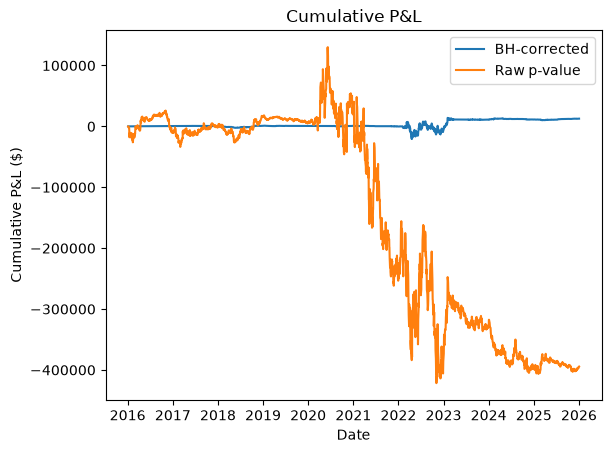

In [88]:
bh_days, bh_pnls = zip(*bh_cummulative_pnl)
sig_days, sig_pnls = zip(*sig_cummulative_pnl)

plt.plot(bh_days, bh_pnls, label="BH-corrected")
plt.plot(sig_days, sig_pnls, label="Raw p-value")

plt.xlabel("Date")
plt.ylabel("Cumulative P&L ($)")
plt.title("Cumulative P&L")
plt.legend()
plt.show()

In [ ]:
def calculate_trade_stats(trades_df):
    return {
        "num_trades": len(trades_df),
        "total_net_pnl": trades_df["net_pnl"].sum(),
        "avg_trade_return": trades_df["trade_return"].mean(),
        "median_trade_return": trades_df["trade_return"].median(),
        "win_rate": (trades_df["net_pnl"] > 0).mean(),
        "avg_holding_days": trades_df["holding_days"].mean(),
        "mean_reversion_rate": trades_df["exit_reason"].eq("mean_reversion").mean(),
        "profit_factor": trades_df.loc[trades_df["net_pnl"] > 0, "net_pnl"].sum()/abs(trades_df.loc[trades_df["net_pnl"] < 0, "net_pnl"].sum())
    }

In [90]:
bh_stats = calculate_trade_stats(bh_trades_df)
sig_stats = calculate_trade_stats(sig_trades_df)

In [91]:
print(bh_stats)
print(sig_stats)

{'num_trades': 155, 'total_net_pnl': np.float64(12579.113416474764), 'avg_trade_return': np.float64(0.008115557042886952), 'median_trade_return': np.float64(0.032928290381903064), 'win_rate': np.float64(0.6580645161290323), 'avg_holding_days': np.float64(219.81935483870967), 'mean_reversion_rate': np.float64(0.5612903225806452), 'profit_factor': np.float64(1.273634420120127)}
{'num_trades': 4246, 'total_net_pnl': np.float64(-369394.4385578269), 'avg_trade_return': np.float64(-0.008699821916105204), 'median_trade_return': np.float64(0.03420492644975542), 'win_rate': np.float64(0.6650965614696185), 'avg_holding_days': np.float64(204.24634950541687), 'mean_reversion_rate': np.float64(0.6241168158266603), 'profit_factor': np.float64(0.8105415948367207)}
